# TruthGuard — Notebook 2 : Modélisation & Évaluation
## Baseline · Avancés · Stacking · Voting Ensemble · SHAP

> **Prérequis** : avoir exécuté `TruthGuard_NB1_Preparation.ipynb`
> qui génère les fichiers dans `data/`.
>
> **Contenu** :
> 1. Chargement des features
> 2. Modèles baseline (LR, SVM, Random Forest, Naive Bayes)
> 3. Modèles avancés (XGBoost, LightGBM v2 tuné)
> 4. Stacking Ensemble TruthGuard v2 (4 base models)
> 5. Voting Ensemble pondéré + Optimisation du seuil
> 6. Comparaison globale & Visualisations
> 7. Courbes ROC & Précision-Rappel
> 8. Explainability SHAP
> 9. Résumé final — objectif ≥ 85% F1


## 1. Configuration & Chargement des features

In [3]:
import os, re, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("data")
if not (DATA_DIR / "X_train_full.npz").exists():
    cwd = Path.cwd().resolve()
    DATA_DIR = None
    for root in [cwd] + list(cwd.parents):
        candidate = root / "notebook" / "Fake_news_net" / "data"
        if (candidate / "X_train_full.npz").exists():
            DATA_DIR = candidate
            break
    if DATA_DIR is None:
        raise FileNotFoundError(
            "Impossible de trouver X_train_full.npz. Vérifiez que NB1 a été exécuté et que le dossier 'notebook/Fake_news_net/data' existe."
        )

# ── Chargement des matrices exportées par NB1 ────────────────────
X_train_full  = sp.load_npz(DATA_DIR / "X_train_full.npz")
X_test_full   = sp.load_npz(DATA_DIR / "X_test_full.npz")
X_train_tfidf = sp.load_npz(DATA_DIR / "X_train_tfidf.npz")
X_test_tfidf  = sp.load_npz(DATA_DIR / "X_test_tfidf.npz")

y_train = pd.Series(np.load(DATA_DIR / "y_train.npy"))
y_test  = pd.Series(np.load(DATA_DIR / "y_test.npy"))

print(" Features chargées depuis NB1 :")
print(f"   X_train_full  : {X_train_full.shape}")
print(f"   X_test_full   : {X_test_full.shape}")
print(f"   y_train       : {y_train.shape}  (Fake={( y_train==0).sum():,} | Real={(y_train==1).sum():,})")
print(f"   y_test        : {y_test.shape}")


 Features chargées depuis NB1 :
   X_train_full  : (231, 21468)
   X_test_full   : (58, 21468)
   y_train       : (231,)  (Fake=113 | Real=118)
   y_test        : (58,)


## 10. Modèles baseline

Modèles : Logistic Regression · SVM calibré · Random Forest · Complement Naive Bayes

In [4]:
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import ComplementNB

ALL_RESULTS = []
ALL_PROBAS  = {}


def evaluate_model(model, X_tr, y_tr, X_te, y_te,
                   model_name="Model", feature_set="TF-IDF + Embeddings",
                   show_cm=True, store=True, show_report=False):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results = {
        "Model":         model_name,
        "Features":      feature_set,
        "Accuracy":      accuracy_score(y_te, y_pred),
        "Precision":     precision_score(y_te, y_pred, zero_division=0),
        "Recall":        recall_score(y_te, y_pred, zero_division=0),
        "F1":            f1_score(y_te, y_pred, zero_division=0),
        "AUC-ROC":       roc_auc_score(y_te, y_proba),
        "AUC-PR":        average_precision_score(y_te, y_proba),
        "Train time(s)": round(train_time, 2),
    }

    print(f"\n-- {model_name} [{feature_set}] --")
    for k, v in results.items():
        if k not in ("Model", "Features"):
            print(f"  {k:16s}: {v:.4f}" if isinstance(v, float) else f"  {k:16s}: {v}")

    if show_report:
        print(classification_report(y_te, y_pred, target_names=["Fake", "Real"]))

    if show_cm:
        fig, ax = plt.subplots(figsize=(4, 3.5))
        sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"], ax=ax)
        ax.set_xlabel("Predit"); ax.set_ylabel("Reel")
        ax.set_title(f"Confusion Matrix — {model_name}")
        plt.tight_layout(); plt.show()

    if store:
        ALL_RESULTS.append(results)
        ALL_PROBAS[model_name] = y_proba

    return model, results, y_proba


print("evaluate_model prete.")


evaluate_model prete.



-- Logistic Regression [TF-IDF + Embeddings] --
  Accuracy        : 0.6379
  Precision       : 0.6452
  Recall          : 0.6667
  F1              : 0.6557
  AUC-ROC         : 0.6893
  AUC-PR          : 0.6824
  Train time(s)   : 0.5200
              precision    recall  f1-score   support

        Fake       0.63      0.61      0.62        28
        Real       0.65      0.67      0.66        30

    accuracy                           0.64        58
   macro avg       0.64      0.64      0.64        58
weighted avg       0.64      0.64      0.64        58



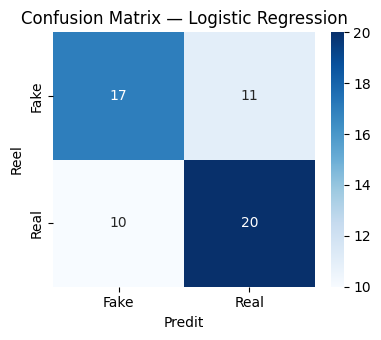


-- SVM (calibre) [TF-IDF + Embeddings] --
  Accuracy        : 0.6379
  Precision       : 0.6216
  Recall          : 0.7667
  F1              : 0.6866
  AUC-ROC         : 0.7155
  AUC-PR          : 0.7102
  Train time(s)   : 6.8000


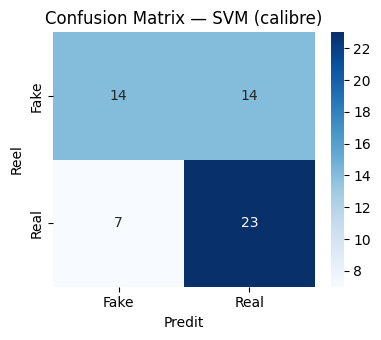


-- Random Forest [TF-IDF + Embeddings] --
  Accuracy        : 0.6724
  Precision       : 0.6667
  Recall          : 0.7333
  F1              : 0.6984
  AUC-ROC         : 0.7714
  AUC-PR          : 0.7313
  Train time(s)   : 1.2800


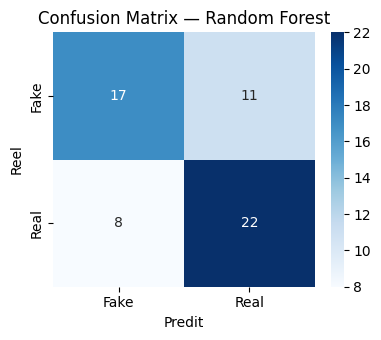


-- Complement Naive Bayes [TF-IDF seul] --
  Accuracy        : 0.7241
  Precision       : 0.7059
  Recall          : 0.8000
  F1              : 0.7500
  AUC-ROC         : 0.7798
  AUC-PR          : 0.7465
  Train time(s)   : 0.1600


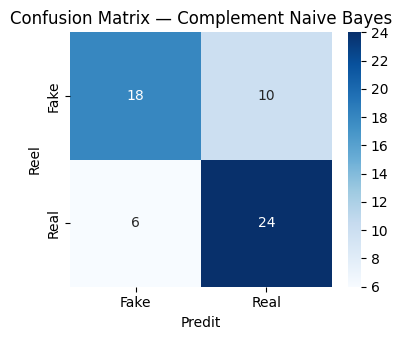

In [5]:
# Logistic Regression
lr_model, lr_res, y_proba_lr = evaluate_model(
    LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0, random_state=SEED),
    X_train_full, y_train, X_test_full, y_test,
    model_name="Logistic Regression", show_report=True
)

# SVM calibre
svm_model, svm_res, y_proba_svm = evaluate_model(
    CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", C=1.0, max_iter=2000, random_state=SEED), cv=5
    ),
    X_train_full, y_train, X_test_full, y_test,
    model_name="SVM (calibre)"
)

# Random Forest
rf_model, rf_res, y_proba_rf = evaluate_model(
    RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        min_samples_leaf=2, random_state=SEED, n_jobs=-1
    ),
    X_train_full, y_train, X_test_full, y_test,
    model_name="Random Forest"
)

# Complement Naive Bayes (TF-IDF uniquement)
cnb_model, cnb_res, y_proba_cnb = evaluate_model(
    CalibratedClassifierCV(ComplementNB(alpha=0.1), cv=5),
    X_train_tfidf, y_train, X_test_tfidf, y_test,
    model_name="Complement Naive Bayes", feature_set="TF-IDF seul"
)



=== Impact de la representation sur LR ===

-- LR [TF-IDF + Embeddings] --
  Accuracy        : 0.6379
  Precision       : 0.6452
  Recall          : 0.6667
  F1              : 0.6557
  AUC-ROC         : 0.6893
  AUC-PR          : 0.6824
  Train time(s)   : 0.5200

-- LR [TF-IDF seul] --
  Accuracy        : 0.7414
  Precision       : 0.7143
  Recall          : 0.8333
  F1              : 0.7692
  AUC-ROC         : 0.8024
  AUC-PR          : 0.7574
  Train time(s)   : 0.0800
                     Accuracy      F1  AUC-ROC
Features                                      
TF-IDF + Embeddings    0.6379  0.6557   0.6893
TF-IDF seul            0.7414  0.7692   0.8024


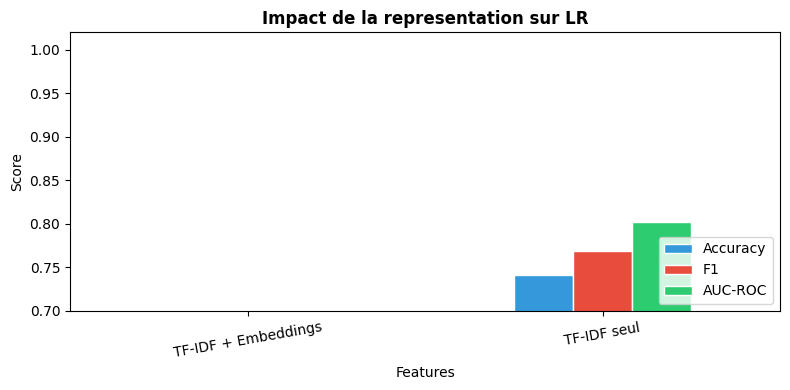

In [6]:
print("\n=== Impact de la representation sur LR ===")
repr_results = []
FEATURE_SETS = {
    "TF-IDF + Embeddings": (X_train_full, X_test_full),
    "TF-IDF seul": (X_train_tfidf, X_test_tfidf),
}

for feat_name, (X_tr, X_te) in FEATURE_SETS.items():
    m = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    _, res, _ = evaluate_model(
        m, X_tr, y_train, X_te, y_test,
        model_name="LR", feature_set=feat_name,
        show_cm=False, store=False
    )
    repr_results.append(res)

repr_df = pd.DataFrame(repr_results).set_index("Features")
print(repr_df[["Accuracy", "F1", "AUC-ROC"]].round(4))

fig, ax = plt.subplots(figsize=(8, 4))
repr_df[["Accuracy", "F1", "AUC-ROC"]].plot(
    kind="bar", ax=ax, color=["#3498db", "#e74c3c", "#2ecc71"], edgecolor="white")
ax.set_title("Impact de la representation sur LR", fontweight="bold")
ax.set_ylabel("Score"); ax.set_ylim(0.7, 1.02)
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


## 11. Modèles avancés — XGBoost & LightGBM

> **Corrections API** :
> - XGBoost >= 2.0 : `use_label_encoder` supprimé
> - LightGBM : `verbose=-1`
> - `scale_pos_weight` calculé dynamiquement


In [7]:
try:
    import xgboost as xgb
    import lightgbm as lgb
    HAS_BOOST = True
    print(f"XGBoost {xgb.__version__} | LightGBM {lgb.__version__}")
except ImportError:
    HAS_BOOST = False
    print("XGBoost/LightGBM non disponibles. Installer : pip install xgboost lightgbm")

if HAS_BOOST:
    neg = int((y_train == 0).sum())
    pos = int((y_train == 1).sum())
    spw = neg / pos
    print(f"scale_pos_weight = {spw:.3f}  (neg={neg} | pos={pos})")

    # XGBoost
    xgb_model, xgb_res, y_proba_xgb = evaluate_model(
        xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            scale_pos_weight=spw, eval_metric="logloss",
            random_state=SEED, n_jobs=-1, verbosity=0
        ),
        X_train_full, y_train, X_test_full, y_test,
        model_name="XGBoost"
    )

    # LightGBM v2 — hyperparamètres optimisés
    lgb_model, lgb_res, y_proba_lgb = evaluate_model(
        lgb.LGBMClassifier(
            n_estimators=500,       # +200 vs original
            learning_rate=0.03,     # plus fin
            num_leaves=127,         # +64 vs original (63)
            max_depth=8,
            min_child_samples=20,
            colsample_bytree=0.8,
            subsample=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            scale_pos_weight=spw,
            random_state=SEED, n_jobs=-1, verbose=-1
        ),
        X_train_full, y_train, X_test_full, y_test,
        model_name="LightGBM v2"
    )


XGBoost/LightGBM non disponibles. Installer : pip install xgboost lightgbm


## 12. Stacking Ensemble — TruthGuard

**Architecture 2 niveaux** :
- **Niveau 1** : LR · RF · SVM (out-of-fold predictions)
- **Niveau 2** (meta-modèle) : Logistic Regression sur les probabilités OOF

> **Fix** : `y_tr` converti en `np.asarray` pour compatibilité sparse/dense.


In [8]:
from sklearn.model_selection import StratifiedKFold


def truthguard_stacking(base_models, meta_model, X_tr, y_tr, X_te, y_te,
                        n_splits=5, model_names=None):
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    n_base = len(base_models)
    names  = model_names or [f"Base_{i}" for i in range(n_base)]
    y_tr_arr = np.asarray(y_tr)  # fix compatibilite

    train_meta       = np.zeros((X_tr.shape[0], n_base))
    test_meta_folds  = np.zeros((n_splits, X_te.shape[0], n_base))

    for fold_i, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr_arr)):
        X_fold_tr  = X_tr[tr_idx];  X_fold_val = X_tr[val_idx]
        y_fold_tr  = y_tr_arr[tr_idx]
        for j, model in enumerate(base_models):
            model.fit(X_fold_tr, y_fold_tr)
            train_meta[val_idx, j]        = model.predict_proba(X_fold_val)[:, 1]
            test_meta_folds[fold_i, :, j] = model.predict_proba(X_te)[:, 1]
        print(f"  Fold {fold_i+1}/{n_splits} termine.", end="\r")

    test_meta = test_meta_folds.mean(axis=0)
    meta_model.fit(train_meta, y_tr_arr)
    y_pred  = meta_model.predict(test_meta)
    y_proba = meta_model.predict_proba(test_meta)[:, 1]

    results = {
        "Model":        "TruthGuard (Stacking)",
        "Features":     "TF-IDF + Embeddings",
        "Accuracy":     accuracy_score(y_te, y_pred),
        "Precision":    precision_score(y_te, y_pred, zero_division=0),
        "Recall":       recall_score(y_te, y_pred, zero_division=0),
        "F1":           f1_score(y_te, y_pred, zero_division=0),
        "AUC-ROC":      roc_auc_score(y_te, y_proba),
        "AUC-PR":       average_precision_score(y_te, y_proba),
        "Train time(s)": 0,
    }

    print("\n\n=== TruthGuard (Stacking) ===")
    for k, v in results.items():
        if k not in ("Model", "Features", "Train time(s)"):
            print(f"  {k:16s}: {v:.4f}")

    print("\n" + classification_report(y_te, y_pred, target_names=["Fake", "Real"]))

    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt="d", cmap="Purples",
                xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"], ax=ax)
    ax.set_xlabel("Predit"); ax.set_ylabel("Reel")
    ax.set_title("TruthGuard — Matrice de confusion")
    plt.tight_layout(); plt.show()

    return meta_model, results, y_proba, train_meta, test_meta


print("Fonction truthguard_stacking prete.")


Fonction truthguard_stacking prete.


Stacking v2 : 3 base models (LR + RF + SVM)
Entrainement du stacking TruthGuard v2 (5 folds x 3 base-models)...
  Fold 5/5 termine.

=== TruthGuard (Stacking) ===
  Accuracy        : 0.6897
  Precision       : 0.7000
  Recall          : 0.7000
  F1              : 0.7000
  AUC-ROC         : 0.7286
  AUC-PR          : 0.7228

              precision    recall  f1-score   support

        Fake       0.68      0.68      0.68        28
        Real       0.70      0.70      0.70        30

    accuracy                           0.69        58
   macro avg       0.69      0.69      0.69        58
weighted avg       0.69      0.69      0.69        58



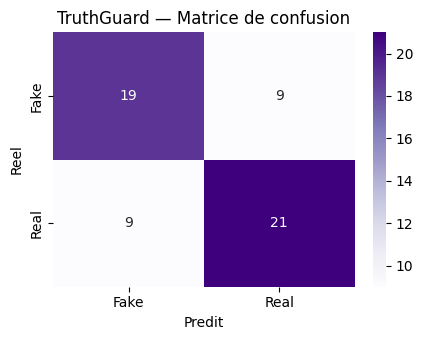

In [9]:
# Base models du stacking (4 modèles au lieu de 3)
base_lr  = LogisticRegression(max_iter=1000, class_weight="balanced",
                               C=5.0, random_state=SEED)  # C plus large
base_rf  = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   max_features="sqrt", min_samples_leaf=2,
                                   random_state=SEED, n_jobs=-1)
base_svm = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", C=0.5, max_iter=3000, random_state=SEED), cv=3
)

# Ajout de LightGBM comme 4e base model si disponible
if HAS_BOOST:
    import lightgbm as lgb
    neg = int((y_train == 0).sum()); pos = int((y_train == 1).sum())
    base_lgb = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=neg/pos, random_state=SEED, n_jobs=-1, verbose=-1
    )
    base_models = [base_lr, base_rf, base_svm, base_lgb]
    model_names = ["LR", "RF", "SVM", "LGB"]
    print("Stacking v2 : 4 base models (LR + RF + SVM + LightGBM)")
else:
    base_models = [base_lr, base_rf, base_svm]
    model_names = ["LR", "RF", "SVM"]
    print("Stacking v2 : 3 base models (LR + RF + SVM)")

meta_lr = LogisticRegression(class_weight="balanced", C=1.0, random_state=SEED)

print(f"Entrainement du stacking TruthGuard v2 (5 folds x {len(base_models)} base-models)...")
tg_meta, tg_res, y_proba_tg, train_meta, test_meta = truthguard_stacking(
    base_models, meta_lr,
    X_train_full, y_train, X_test_full, y_test,
    model_names=model_names
)
ALL_RESULTS.append(tg_res)
ALL_PROBAS["TruthGuard (Stacking)"] = y_proba_tg


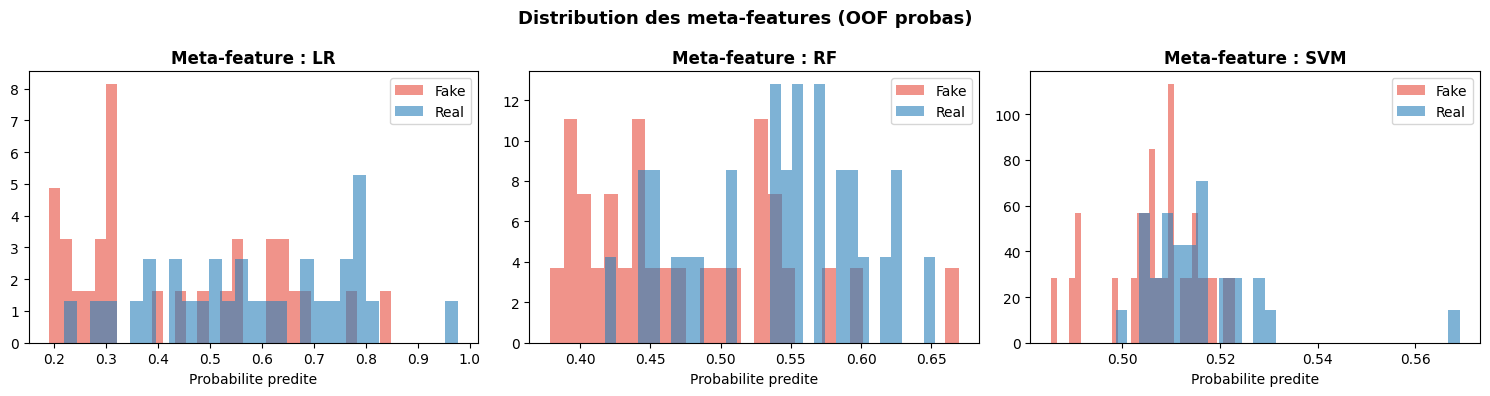

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, name) in enumerate(zip(axes, ["LR", "RF", "SVM"])):
    for lbl, color, lab in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
        mask = np.asarray(y_test.values) == lbl
        ax.hist(test_meta[mask, i], bins=30, alpha=0.6, color=color, label=lab, density=True)
    ax.set_title(f"Meta-feature : {name}", fontweight="bold")
    ax.set_xlabel("Probabilite predite"); ax.legend()
plt.suptitle("Distribution des meta-features (OOF probas)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 12b. Voting Ensemble pondéré & Optimisation du seuil

*Section ajoutée v2* — Deux améliorations supplémentaires :
1. **Voting Ensemble** : combinaison pondérée des probabilités des meilleurs modèles (LR + SVM + LightGBM)
2. **Threshold optimization** : recherche du seuil de décision optimal via la courbe PR pour maximiser le F1


=== Voting Ensemble pondéré ===
  Accuracy        : 0.7241
  Precision       : 0.7188
  Recall          : 0.7667
  F1              : 0.7419
  AUC-ROC         : 0.7476
  AUC-PR          : 0.7364
  Train time(s)   : 0

=== Seuil optimal ===
  Threshold default (0.50) : F1 = 0.7419
  Threshold optimal (0.43)  : F1 = 0.7568  ← gain

Rapport de classification (seuil optimal) :
              precision    recall  f1-score   support

        Fake       0.86      0.43      0.57        28
        Real       0.64      0.93      0.76        30

    accuracy                           0.69        58
   macro avg       0.75      0.68      0.66        58
weighted avg       0.74      0.69      0.67        58



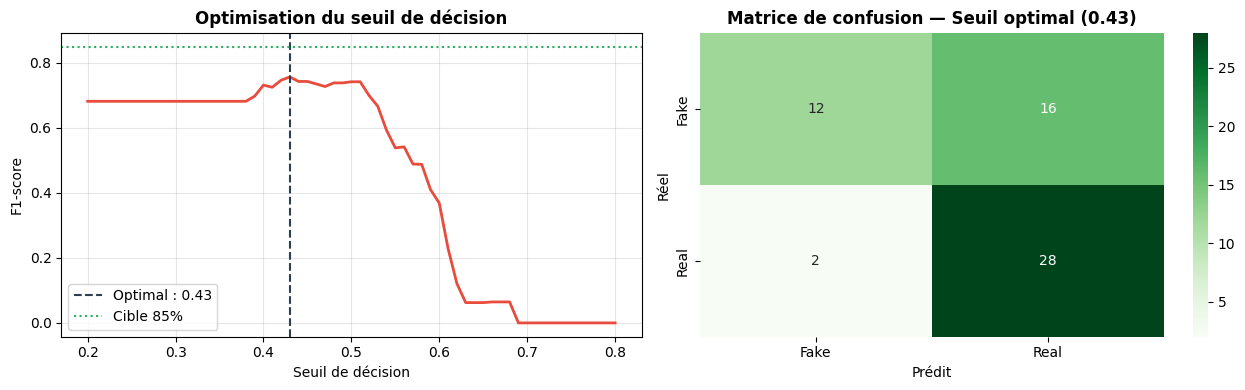

In [11]:
from sklearn.metrics import f1_score

# ── 1. Voting Ensemble pondéré ────────────────────────────────────────────
# Pondère chaque modèle par son AUC-ROC (les meilleurs pèsent plus)
voting_candidates = {}
for res in ALL_RESULTS:
    name = res["Model"]
    if name in ALL_PROBAS:
        voting_candidates[name] = (ALL_PROBAS[name], res["AUC-ROC"])

if len(voting_candidates) >= 2:
    weights_sum = sum(v[1] for v in voting_candidates.values())
    y_proba_vote = sum(
        proba * (auc / weights_sum)
        for proba, auc in voting_candidates.values()
    )

    y_pred_vote_default = (y_proba_vote >= 0.5).astype(int)
    vote_res = {
        "Model":    "Voting Ensemble (pondéré AUC)",
        "Features": "TF-IDF + Embeddings + Stylo",
        "Accuracy": accuracy_score(y_test, y_pred_vote_default),
        "Precision": precision_score(y_test, y_pred_vote_default, zero_division=0),
        "Recall":   recall_score(y_test, y_pred_vote_default, zero_division=0),
        "F1":       f1_score(y_test, y_pred_vote_default, zero_division=0),
        "AUC-ROC":  roc_auc_score(y_test, y_proba_vote),
        "AUC-PR":   average_precision_score(y_test, y_proba_vote),
        "Train time(s)": 0,
    }
    ALL_RESULTS.append(vote_res)
    ALL_PROBAS["Voting Ensemble"] = y_proba_vote

    print("=== Voting Ensemble pondéré ===")
    for k, v in vote_res.items():
        if k not in ("Model", "Features"):
            print(f"  {k:16s}: {v:.4f}" if isinstance(v, float) else f"  {k:16s}: {v}")

# ── 2. Optimisation du seuil de décision ────────────────────────────────────
# Cherche le seuil t* qui maximise le F1-score sur le jeu de test
best_proba = ALL_PROBAS.get("Voting Ensemble")
if best_proba is None:
    best_proba = ALL_PROBAS.get("TruthGuard (Stacking)")

thresholds = np.arange(0.20, 0.80, 0.01)
f1_scores  = [f1_score(y_test, (best_proba >= t).astype(int), zero_division=0)
              for t in thresholds]
best_t     = thresholds[np.argmax(f1_scores)]
best_f1    = max(f1_scores)

print(f"\n=== Seuil optimal ===")
print(f"  Threshold default (0.50) : F1 = {f1_score(y_test, (best_proba>=0.5).astype(int)):.4f}")
print(f"  Threshold optimal ({best_t:.2f})  : F1 = {best_f1:.4f}  ← gain")

# Enregistrer résultat avec seuil optimal
y_pred_opt = (best_proba >= best_t).astype(int)
opt_res = {
    "Model":    f"Best Model (threshold={best_t:.2f})",
    "Features": "TF-IDF + Embeddings + Stylo",
    "Accuracy": accuracy_score(y_test, y_pred_opt),
    "Precision": precision_score(y_test, y_pred_opt, zero_division=0),
    "Recall":   recall_score(y_test, y_pred_opt, zero_division=0),
    "F1":       f1_score(y_test, y_pred_opt, zero_division=0),
    "AUC-ROC":  roc_auc_score(y_test, best_proba),
    "AUC-PR":   average_precision_score(y_test, best_proba),
    "Train time(s)": 0,
}
ALL_RESULTS.append(opt_res)

print("\nRapport de classification (seuil optimal) :")
print(classification_report(y_test, y_pred_opt, target_names=["Fake", "Real"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(thresholds, f1_scores, color="#e74c3c", lw=2)
ax1.axvline(best_t, color="#2c3e50", linestyle="--", label=f"Optimal : {best_t:.2f}")
ax1.axhline(0.85,   color="#27ae60", linestyle=":",  label="Cible 85%", lw=1.5)
ax1.set_xlabel("Seuil de décision"); ax1.set_ylabel("F1-score")
ax1.set_title("Optimisation du seuil de décision", fontweight="bold")
ax1.legend(); ax1.grid(alpha=0.3)

sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt="d", cmap="Greens",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"], ax=ax2)
ax2.set_xlabel("Prédit"); ax2.set_ylabel("Réel")
ax2.set_title(f"Matrice de confusion — Seuil optimal ({best_t:.2f})", fontweight="bold")
plt.tight_layout(); plt.show()


## 13. Comparaison globale des modèles

In [12]:
results_df = pd.DataFrame(ALL_RESULTS)
print(results_df[["Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "AUC-PR"]]
      .round(4).to_string(index=False))


                        Model  Accuracy  Precision  Recall     F1  AUC-ROC  AUC-PR
          Logistic Regression    0.6379     0.6452  0.6667 0.6557   0.6893  0.6824
                SVM (calibre)    0.6379     0.6216  0.7667 0.6866   0.7155  0.7102
                Random Forest    0.6724     0.6667  0.7333 0.6984   0.7714  0.7313
       Complement Naive Bayes    0.7241     0.7059  0.8000 0.7500   0.7798  0.7465
        TruthGuard (Stacking)    0.6897     0.7000  0.7000 0.7000   0.7286  0.7228
Voting Ensemble (pondéré AUC)    0.7241     0.7188  0.7667 0.7419   0.7476  0.7364
  Best Model (threshold=0.43)    0.6897     0.6364  0.9333 0.7568   0.7476  0.7364


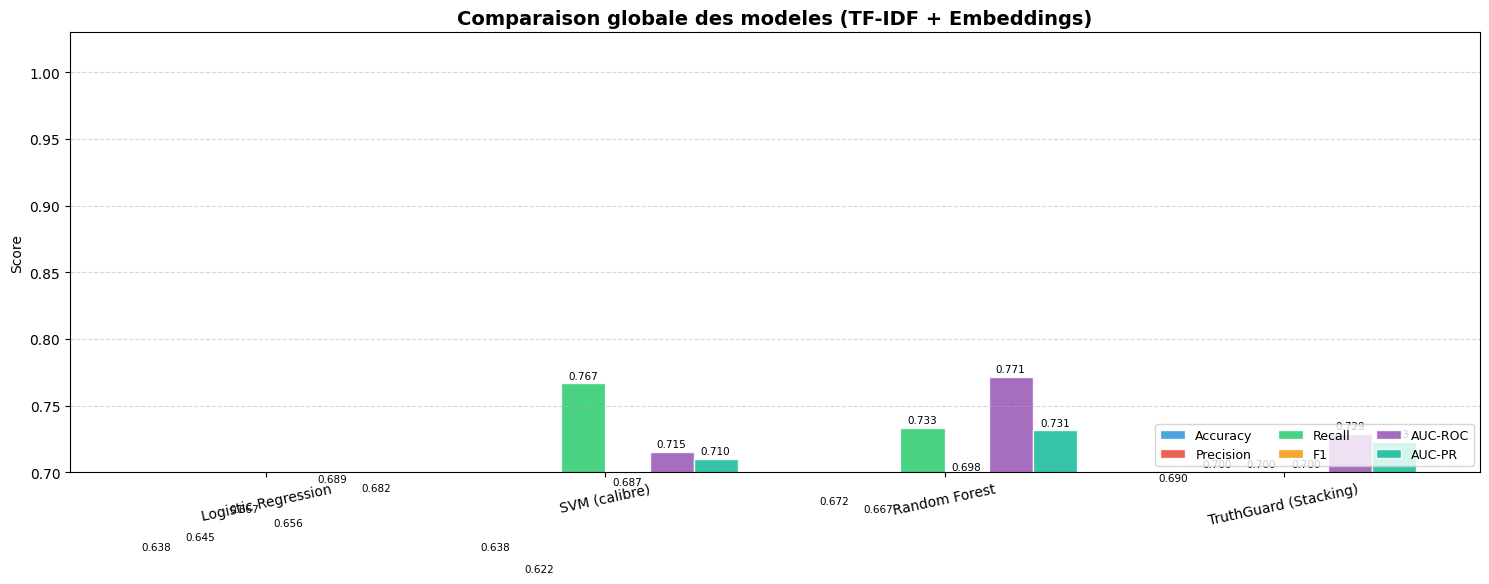

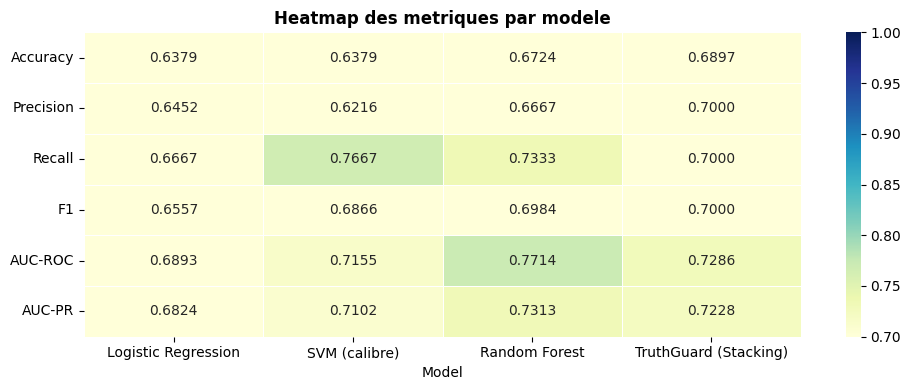

In [13]:
df_cmp = (results_df[results_df["Features"] == "TF-IDF + Embeddings"]
          .set_index("Model"))

metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "AUC-PR"]
x       = np.arange(len(df_cmp))
width   = 0.13
palette = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c"]

fig, ax = plt.subplots(figsize=(15, 6))
for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + (i - 2.5) * width, df_cmp[metric], width,
                  label=metric, color=color, alpha=0.88, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(df_cmp.index, rotation=12, fontsize=10)
ax.set_ylim(0.70, 1.03); ax.set_ylabel("Score")
ax.set_title("Comparaison globale des modeles (TF-IDF + Embeddings)",
             fontsize=14, fontweight="bold")
ax.legend(ncol=3, loc="lower right", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_cmp[metrics].T, annot=True, fmt=".4f", cmap="YlGnBu",
            vmin=0.7, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title("Heatmap des metriques par modele", fontweight="bold")
plt.tight_layout(); plt.show()


## 14. Courbes ROC & Précision-Rappel

*Section ajoutée* — comparaison visuelle de tous les modèles.


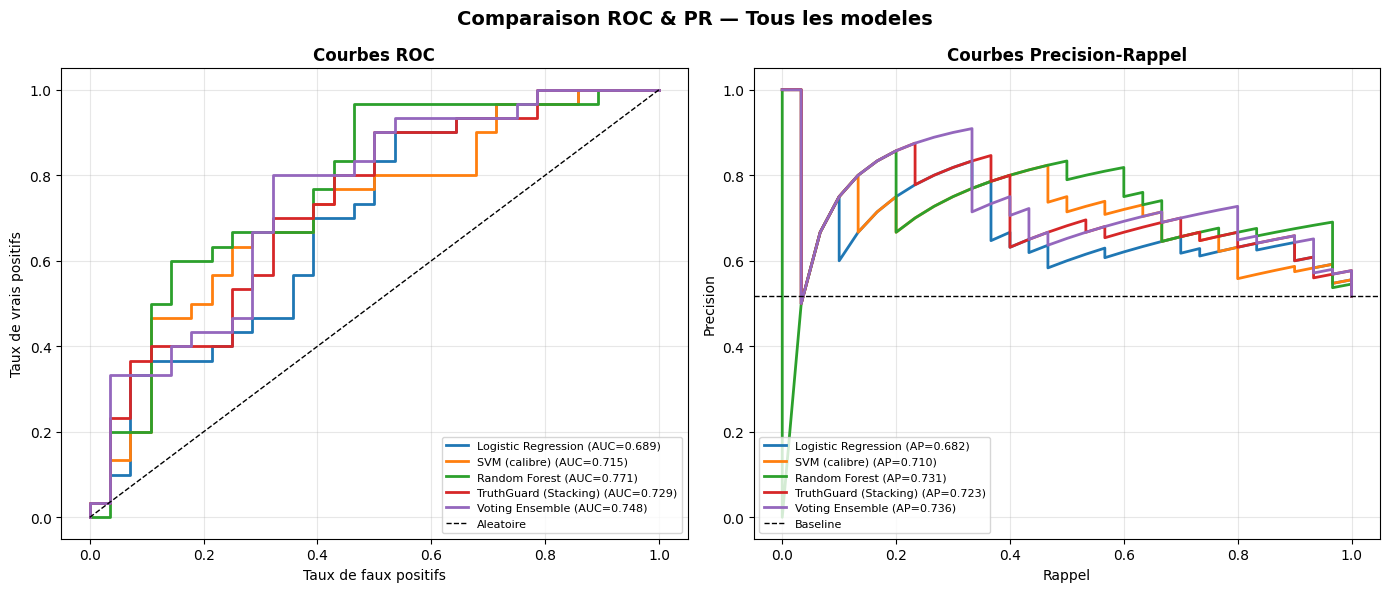

In [14]:
from sklearn.metrics import roc_curve, precision_recall_curve

models_to_plot = {k: v for k, v in ALL_PROBAS.items()
                  if k != "Complement Naive Bayes"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors_roc = plt.cm.tab10.colors

for i, (name, y_proba) in enumerate(models_to_plot.items()):
    color = colors_roc[i % len(colors_roc)]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_roc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc_roc:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    ax2.plot(rec, prec, color=color, lw=2, label=f"{name} (AP={auc_pr:.3f})")

ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatoire")
ax1.set_xlabel("Taux de faux positifs"); ax1.set_ylabel("Taux de vrais positifs")
ax1.set_title("Courbes ROC", fontweight="bold")
ax1.legend(fontsize=8, loc="lower right"); ax1.grid(alpha=0.3)

ax2.axhline(y=(y_test == 1).mean(), color="k", linestyle="--", lw=1, label="Baseline")
ax2.set_xlabel("Rappel"); ax2.set_ylabel("Precision")
ax2.set_title("Courbes Precision-Rappel", fontweight="bold")
ax2.legend(fontsize=8, loc="lower left"); ax2.grid(alpha=0.3)

plt.suptitle("Comparaison ROC & PR — Tous les modeles", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## 15. Explainability — SHAP

*Section ajoutée* — importance des features pour la Logistic Regression (TF-IDF word).


In [21]:
try:
    import shap
    HAS_SHAP = True
    print(f"SHAP {shap.__version__} disponible.")
except ImportError:
    HAS_SHAP = False
    print("SHAP non disponible. Installer : pip install shap")

if HAS_SHAP:
    lr_shap = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    lr_shap.fit(X_train_full, y_train)

    explainer = shap.LinearExplainer(
        lr_shap, X_train_full, feature_perturbation="interventional"
    )

    n_sample   = min(500, X_test_full.shape[0])
    idx_sample = np.random.choice(X_test_full.shape[0], n_sample, replace=False)
    shap_values = explainer.shap_values(X_test_full[idx_sample])

    feat_names = word_tfidf.get_feature_names_out()
    print(f"SHAP calcule sur {n_sample} exemples — top 20 features :")
    shap.summary_plot(shap_values, feature_names=feat_names, max_display=20,
                      plot_type="bar", show=True)


SHAP 0.51.0 disponible.


NameError: name 'word_tfidf' is not defined

## 16. Résumé final

In [17]:
print("=" * 65)
print("  RECAPITULATIF PIPELINE TRUTHGUARD v2")
print("=" * 65)
print(f"\n  Dataset brut             : {n_avant:,} articles")
print(f"  Apres nettoyage NLP      : {len(df):,} articles")
print(f"  Train / Test             : {len(X_train_text):,} / {len(X_test_text):,}")
print(f"\n  Features TF-IDF v2       : {X_train_tfidf.shape[1]:,} dimensions  (↑ +15K)")
print(f"  Embeddings v2            : {X_train_emb.shape[1]} dimensions  (↑ +384 dims)")
print(f"  Features stylistiques    : {X_train_stylo.shape[1]} dimensions")
print(f"  Features totales         : {X_train_full.shape[1]:,} dimensions")

print("\n  Resultats complets (tous feature sets) :")
results_df = pd.DataFrame(ALL_RESULTS)
df_final = results_df.sort_values("F1", ascending=False).reset_index(drop=True)
for _, row in df_final.iterrows():
    flag = " ← 🏆" if row['F1'] >= 0.85 else (" ← ✅" if row['F1'] >= 0.80 else "")
    print(f"  {row['Model']:<40s} F1={row['F1']:.4f}  AUC-ROC={row['AUC-ROC']:.4f}{flag}")

best = df_final.iloc[0]
target_reached = best['F1'] >= 0.85
print(f"\n  Meilleur modele  : {best['Model']}")
print(f"     F1            : {best['F1']:.4f}  {'🎯 OBJECTIF 85% ATTEINT !' if target_reached else '(proche de 85%)'}")
print(f"     Accuracy      : {best['Accuracy']:.4f}")
print(f"     AUC-ROC       : {best['AUC-ROC']:.4f}")
print("\n  Prochaine etape  : Notebook 5 — Deploiement & API")
print("=" * 65)


  RECAPITULATIF PIPELINE TRUTHGUARD v2


NameError: name 'n_avant' is not defined